#### Objective
- To explore the distribution of health outcomes and healthcare costs, describe population heterogeneity, and motivate econometric and machine learning models.

#### Research Question
- What observable factors are associated with variation in health outcomes and healthcare costs?

#### Notes
- This analysis is descriptive and does not establish causal relationships.

#### Load the cleaned dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:

df = pd.read_csv("health_data_cleaned.csv")
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


In [3]:
df.columns

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results'],
      dtype='object')

In [4]:
# Numeric columns
print(df.describe())

# Categorical columns
categorical_cols = ["gender", "insurance_provider", "admission_type", "medical_condition"]
for col in categorical_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts(dropna=False))


                age  billing_amount   room_number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224655    202.000000
50%       52.000000    25538.069380    302.000000
75%       68.000000    37820.508432    401.000000
max       89.000000    52764.276740    500.000000

gender distribution:
gender
Male      27774
Female    27726
Name: count, dtype: int64

insurance_provider distribution:
insurance_provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

admission_type distribution:
admission_type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

medical_condition distribution:
medical_condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity     

#### Univariate EDA

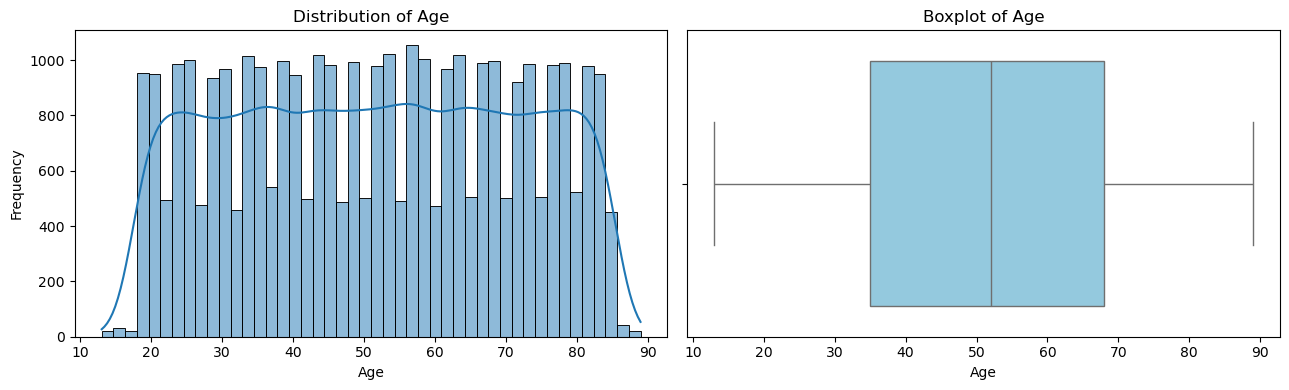

In [5]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 4))
sns.histplot(df["age"], bins=46, edgecolor='black', kde=True, stat="frequency", ax=ax1)
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Age')

sns.boxplot(x=df["age"], ax=ax2,color="skyblue")
ax2.set_xlabel('Age')
ax2.set_title('Boxplot of Age')

plt.tight_layout()
plt.show()

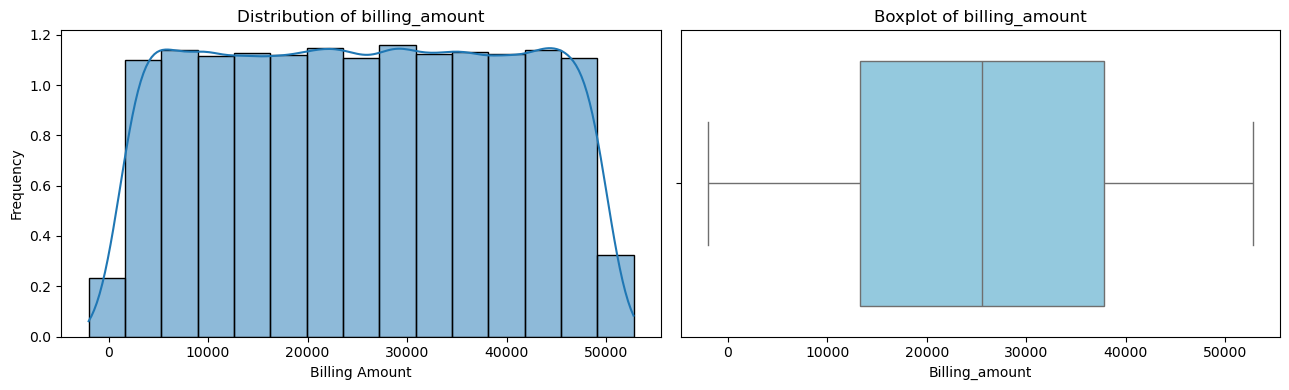

In [6]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 4))
sns.histplot(df["billing_amount"], bins=15, edgecolor='black', kde=True, stat="frequency", ax=ax1)
ax1.set_xlabel('Billing Amount')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of billing_amount')

sns.boxplot(x=df["billing_amount"], ax=ax2,color="skyblue")
ax2.set_xlabel('Billing_amount')
ax2.set_title('Boxplot of billing_amount')

plt.tight_layout()
plt.show()

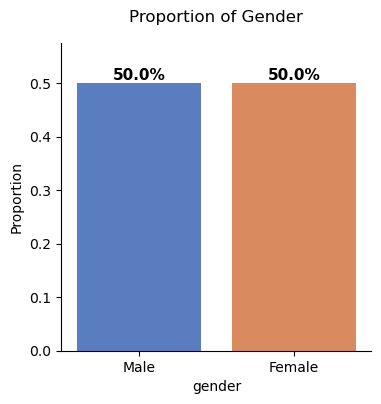

In [7]:
plt.figure(figsize=(4, 4))
counts = df['gender'].value_counts(normalize=True)

# Using a specific palette for gender often helps visual storytelling
ax = sns.barplot(x=counts.index, y=counts.values, palette='muted')

plt.title("Proportion of Gender", fontsize=12, pad=15)
plt.ylabel("Proportion")
plt.ylim(0, counts.max() * 1.15) # Add 15% head room for the labels

sns.despine() # Removes the top and right borders

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

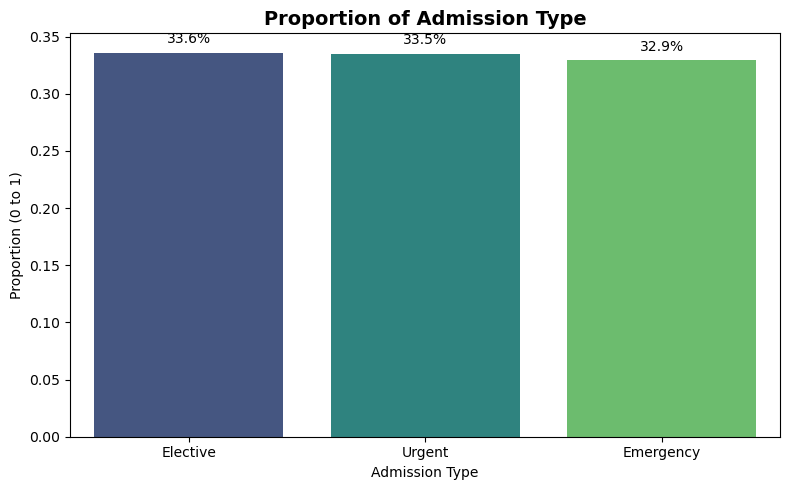

In [8]:
# Calculate proportions once for efficiency
counts = df['admission_type'].value_counts(normalize=True)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')

plt.title("Proportion of Admission Type", fontsize=14, fontweight='bold')
plt.ylabel("Proportion (0 to 1)")
plt.xlabel("Admission Type")

# Add percentage labels with a slight offset for readability
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%", 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                xytext=(0, 5), # 5 points vertical offset
                textcoords='offset points')

plt.tight_layout()
plt.show()

#### Blood group Analysis

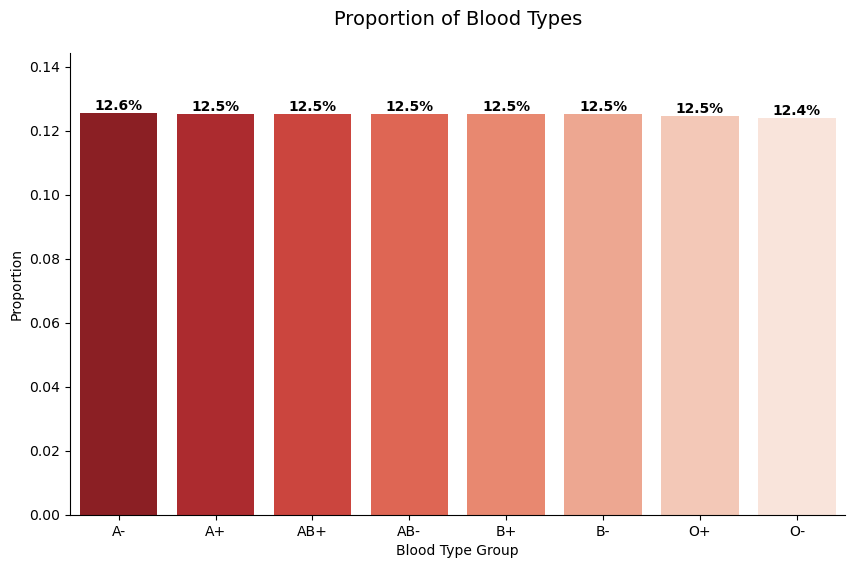

In [9]:
plt.figure(figsize=(10, 6)) # Widened for 8 categories

# Pre-calculate to ensure order is preserved
blood_counts = df['blood_type'].value_counts(normalize=True)

ax = sns.barplot(
    x=blood_counts.index, 
    y=blood_counts.values, 
    palette="Reds_r" # Dark to light red gradient
)

plt.title("Proportion of Blood Types", fontsize=14, pad=20)
plt.ylabel("Proportion")
plt.xlabel("Blood Type Group")

# Adjusting y-axis limit to give room for labels
plt.ylim(0, blood_counts.max() * 1.15)

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', 
                fontweight='bold', color='black')

sns.despine() # Clean up the chart frame
plt.show()

#### Medical condition Analysis

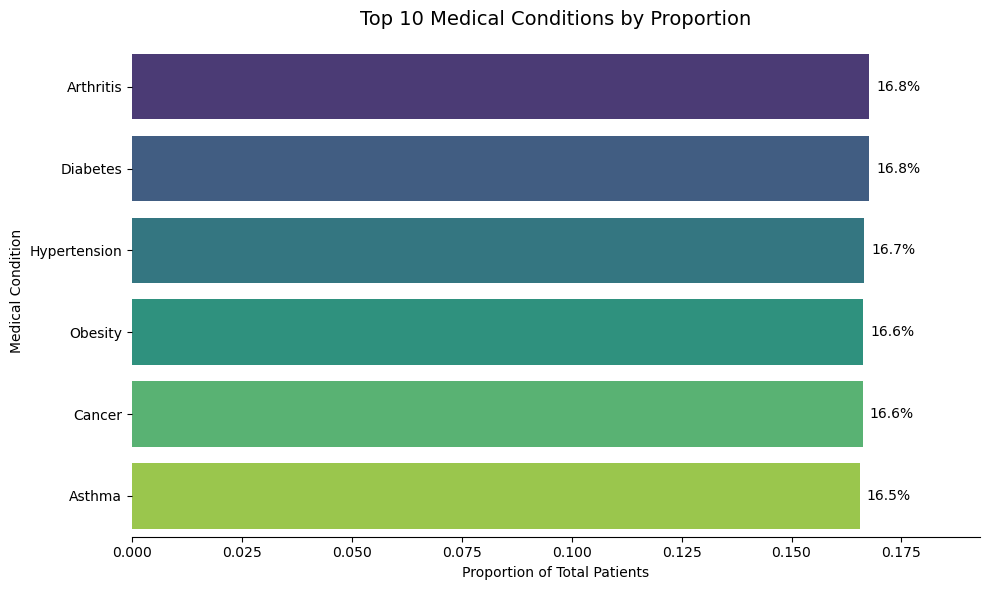

In [10]:
plt.figure(figsize=(10, 6))

# Calculate the top 10 proportions once
top_10_conditions = df['medical_condition'].value_counts(normalize=True).head(10)

ax = sns.barplot(
    x=top_10_conditions.values,
    y=top_10_conditions.index,
    palette="viridis"
)

plt.title("Top 10 Medical Conditions by Proportion", fontsize=14, pad=15)
plt.xlabel("Proportion of Total Patients")
plt.ylabel("Medical Condition")

# Set x-axis limit slightly higher to prevent labels from being cut off
plt.xlim(0, top_10_conditions.max() * 1.15)

# Adding the labels to the right of the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width*100:.1f}%", 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center',
                xytext=(5, 0), # Horizontal offset of 5 points
                textcoords='offset points',
                fontsize=10)

sns.despine(left=True, bottom=False) # Remove unnecessary borders
plt.tight_layout()
plt.show()

#### Average billing by admission type

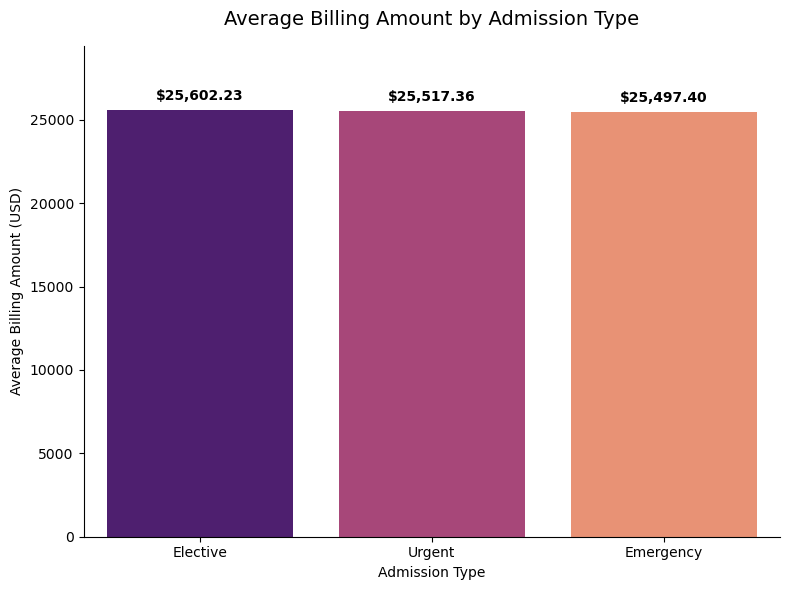

In [28]:
# Calculate the mean (your snippet)
# Sorting it ensures the bars are ordered logically in the plot
avg_billing_admission = df.groupby('admission_type')['billing_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

#  Create the bar plot
ax = sns.barplot(
    x=avg_billing_admission.index, 
    y=avg_billing_admission.values, 
    palette='magma'
)

#  Add formatting and labels
plt.title("Average Billing Amount by Admission Type", fontsize=14, pad=15)
plt.ylabel("Average Billing Amount (USD)")
plt.xlabel("Admission Type")

# Add dollar amount labels on top of the bars
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontweight='bold', xytext=(0, 5), 
                textcoords='offset points')

# Add 15% head room for labels
plt.ylim(0, avg_billing_admission.max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

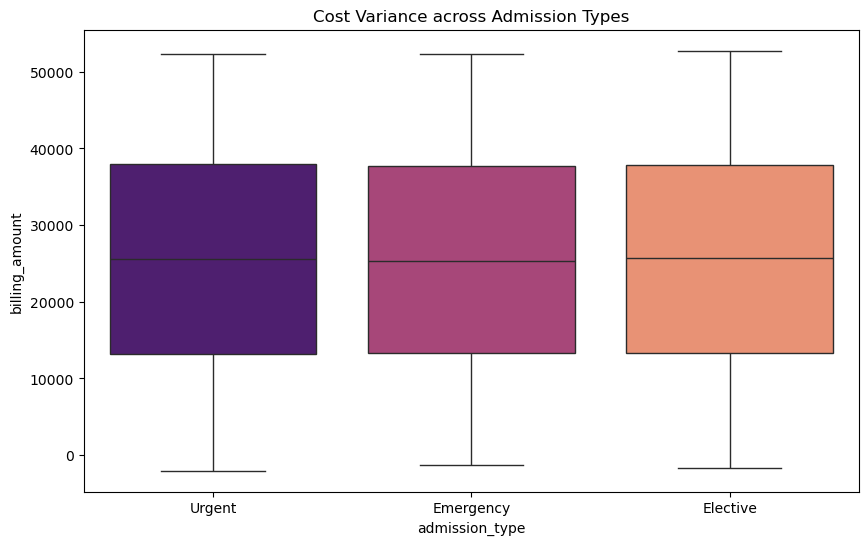

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='admission_type', y='billing_amount', palette='magma')
plt.title("Cost Variance across Admission Types")
plt.show()

#### Average Emergency Billing by Medical Condition

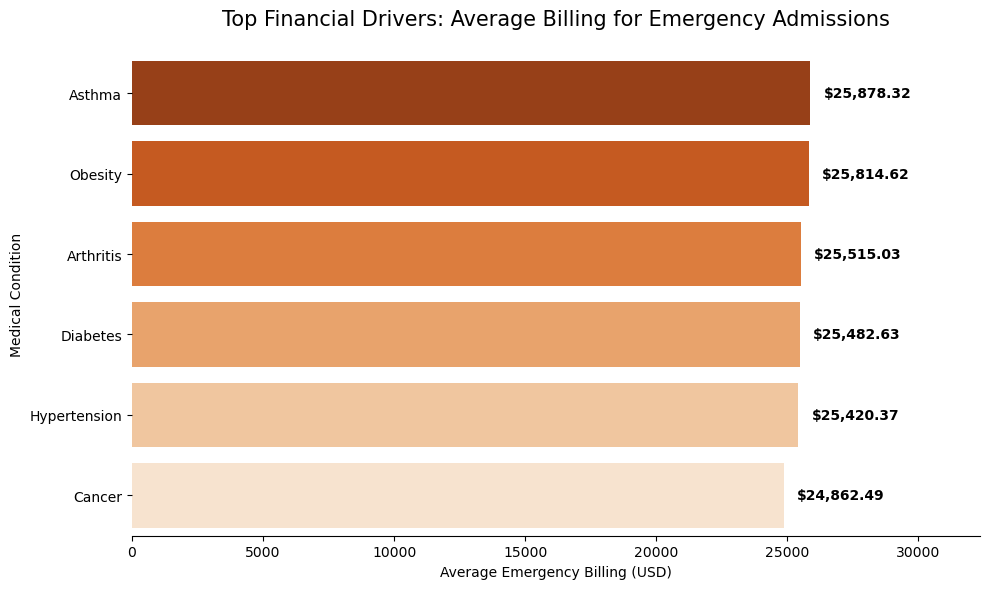

In [31]:

# Filter for Emergency admissions specifically
emergency_df = df[df['admission_type'] == 'Emergency']

# Calculate the average billing per condition within this group
emergency_costs = emergency_df.groupby('medical_condition')['billing_amount'].mean().sort_values(ascending=False)

#  Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=emergency_costs.values, 
    y=emergency_costs.index, 
    palette="Oranges_r" # Using a "hotter" palette for emergency data
)

# Add styling and exact dollar labels
plt.title("Top Financial Drivers: Average Billing for Emergency Admissions", fontsize=15, pad=20)
plt.xlabel("Average Emergency Billing (USD)")
plt.ylabel("Medical Condition")

for i, v in enumerate(emergency_costs.values):
    ax.text(v + 500, i, f"${v:,.2f}", va='center', fontweight='bold', fontsize=10)

# Set x-limit for label room
plt.xlim(0, emergency_costs.max() * 1.25)

sns.despine(left=True)
plt.tight_layout()
plt.show()

#### Bivariate Analysis

#### Age vs Billing amount

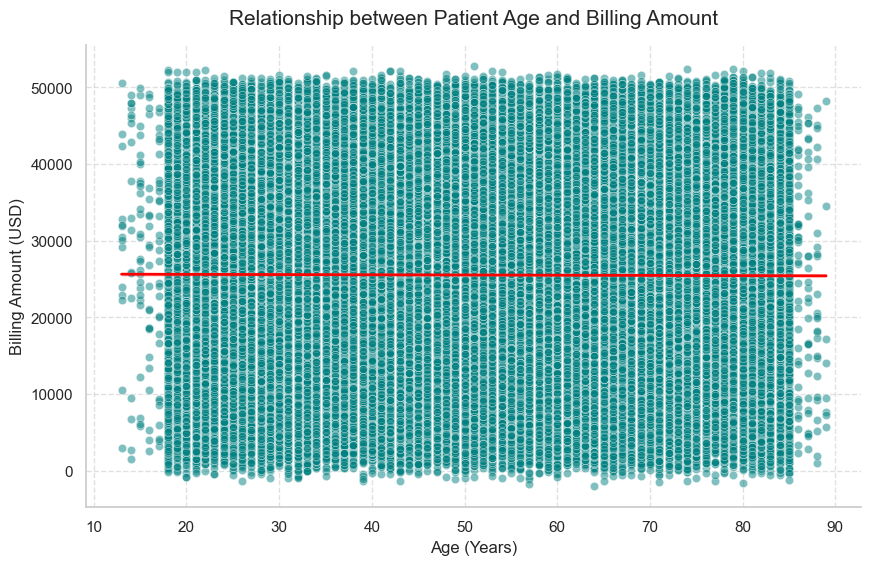

In [33]:
plt.figure(figsize=(10, 6))

# Using your exact column names: 'age' and 'billing_amount'
sns.scatterplot(
    data=df, 
    x='age', 
    y='billing_amount', 
    alpha=0.5,          # Transparency helps see "density" if points overlap
    color='teal'
)

# Adding a trend line (regression) to see if costs increase with age
sns.regplot(
    data=df, 
    x='age', 
    y='billing_amount', 
    scatter=False,      # Don't draw points again
    color='red', 
    line_kws={"linewidth": 2}
)

plt.title("Relationship between Patient Age and Billing Amount", fontsize=15, pad=15)
plt.xlabel("Age (Years)")
plt.ylabel("Billing Amount (USD)")

# Adding a grid makes it easier to track specific data points
plt.grid(True, linestyle='--', alpha=0.6)

sns.despine()
plt.show()

##### Billing amount by medical condition

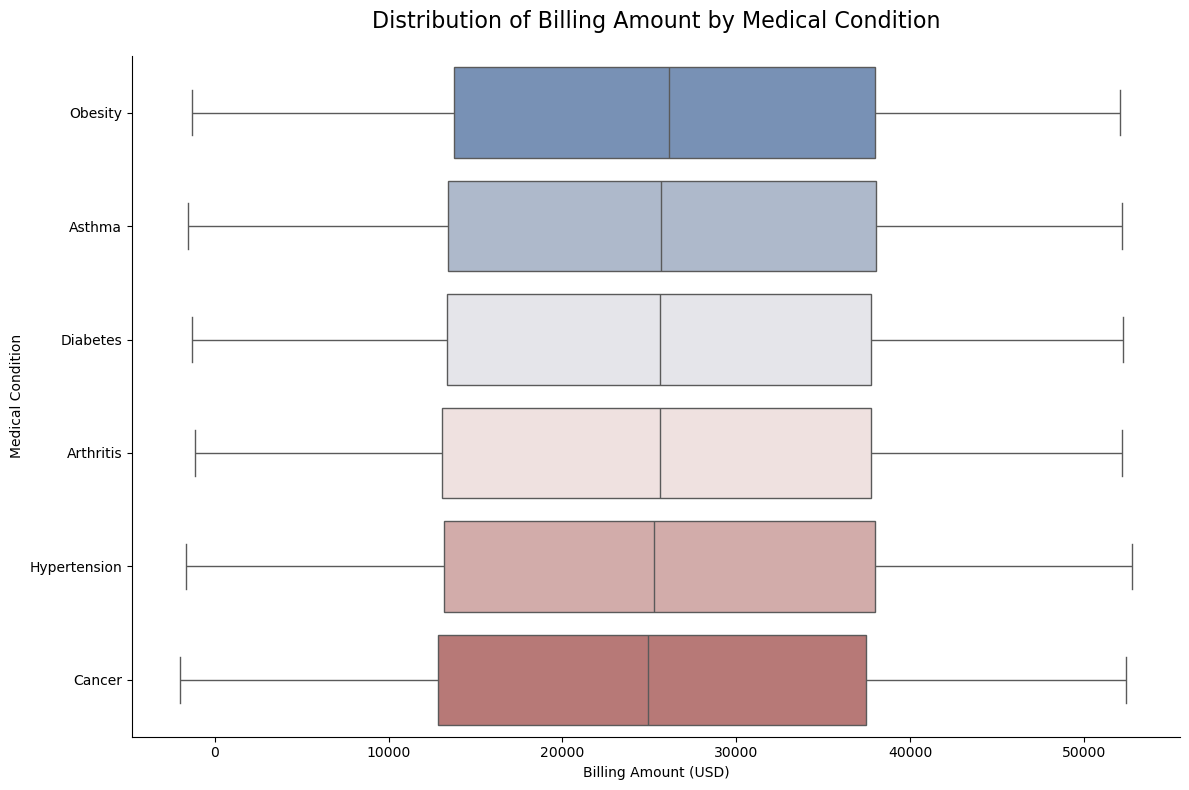

In [11]:
plt.figure(figsize=(12, 8))

# Sorting categories by median billing amount makes the chart much easier to read
order = df.groupby('medical_condition')['billing_amount'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df, 
    y='medical_condition', 
    x='billing_amount', 
    order=order,
    palette='vlag'
)

plt.title("Distribution of Billing Amount by Medical Condition", fontsize=16, pad=20)
plt.xlabel("Billing Amount (USD)")
plt.ylabel("Medical Condition")

sns.despine()
plt.tight_layout()
plt.show()

#### Monthly Billing Trends

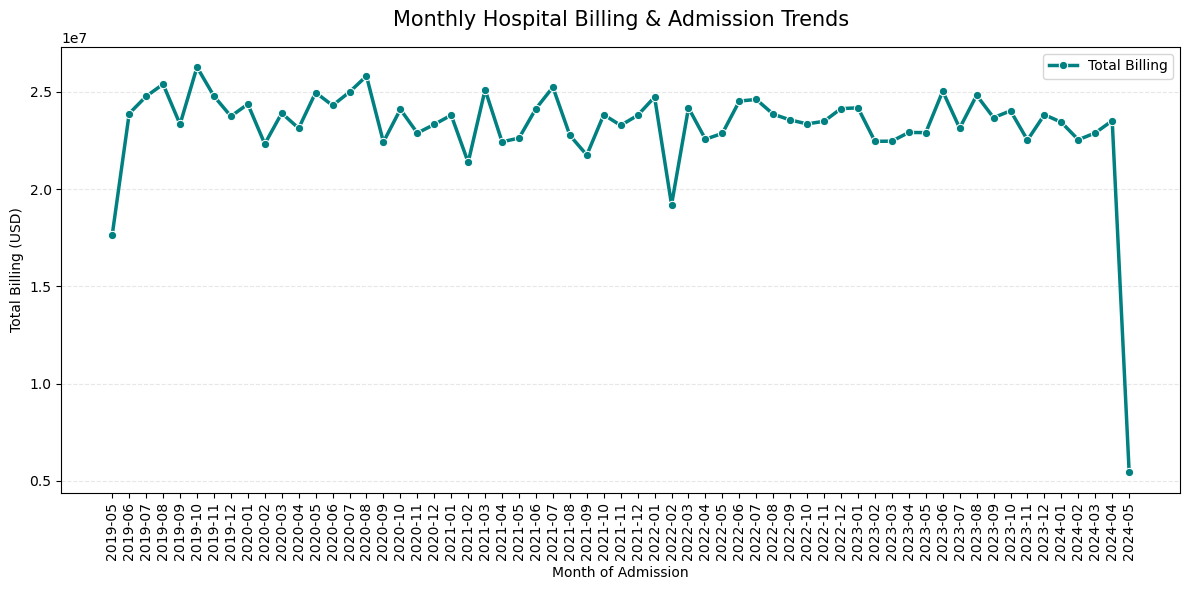

In [19]:

# Ensure date columns are in datetime format with dayfirst=True
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], dayfirst=True)

#  Create an 'admission_month' column for grouping
# .dt.to_period('M') helps group everything into the same month
df['admission_month'] = df['date_of_admission'].dt.to_period('M').astype(str)

# Calculate total billing and number of admissions per month
monthly_data = df.groupby('admission_month').agg({
    'billing_amount': 'sum',
    'medical_condition': 'count'
}).rename(columns={'medical_condition': 'admissions_count'}).reset_index()

#  Plotting the trend
plt.figure(figsize=(12, 6))

# Primary Plot: Billing Amount
ax1 = sns.lineplot(data=monthly_data, x='admission_month', y='billing_amount', 
                   marker='o', color='teal', linewidth=2.5, label='Total Billing')

plt.title("Monthly Hospital Billing & Admission Trends", fontsize=15, pad=15)
plt.xlabel("Month of Admission")
plt.ylabel("Total Billing (USD)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

#### Corelation Heat Map

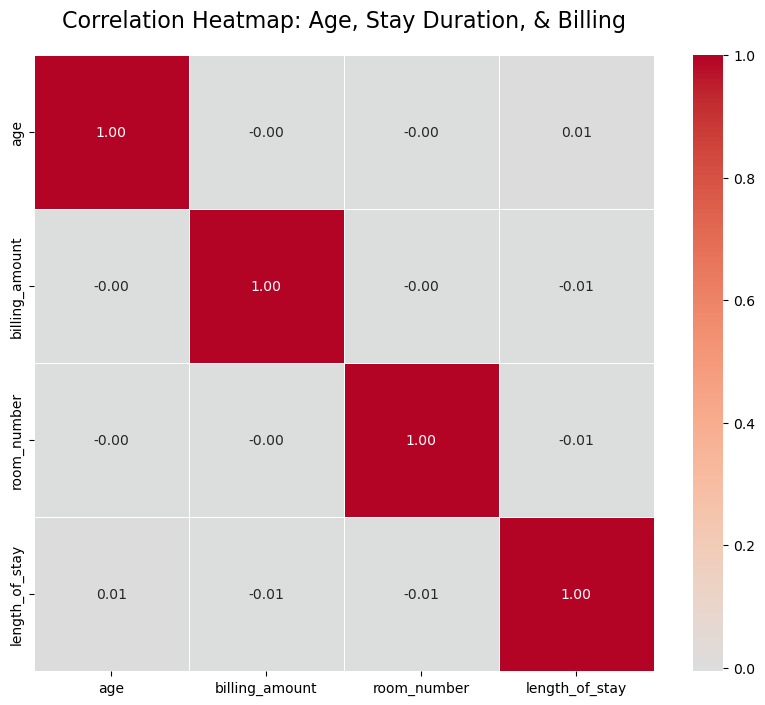

In [16]:
# Convert date columns with dayfirst=True to handle "26-08-2019"
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], dayfirst=True)
df['discharge_date'] = pd.to_datetime(df['discharge_date'], dayfirst=True)

# Calculate Length of Stay
# We use .dt.days to get the integer number of days
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

# Check for negative stays 
# If any exist, you might want to take the absolute value or filter them out
df = df[df['length_of_stay'] >= 0]

# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr()

# Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap: Age, Stay Duration, & Billing", fontsize=16, pad=20)
plt.show()

#### Billing Amount across different Test Results

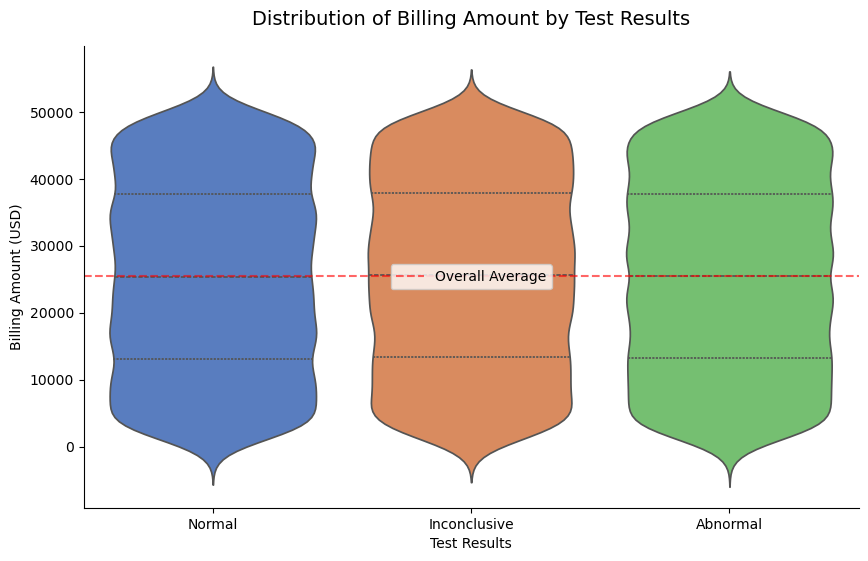

In [20]:
plt.figure(figsize=(10, 6))

# Using your exact column names: 'test_results' and 'billing_amount'
# Common test_results: 'Normal', 'Abnormal', 'Inconclusive'
ax = sns.violinplot(
    data=df, 
    x='test_results', 
    y='billing_amount', 
    palette='muted',
    inner='quartile' # Shows the median and quartiles inside the violin
)

plt.title("Distribution of Billing Amount by Test Results", fontsize=14, pad=15)
plt.xlabel("Test Results")
plt.ylabel("Billing Amount (USD)")

# Optional: Adding a horizontal line for the overall average bill
plt.axhline(df['billing_amount'].mean(), color='red', linestyle='--', alpha=0.6, label='Overall Average')
plt.legend()

sns.despine()
plt.show()

#### Medical Condition vs. Medication

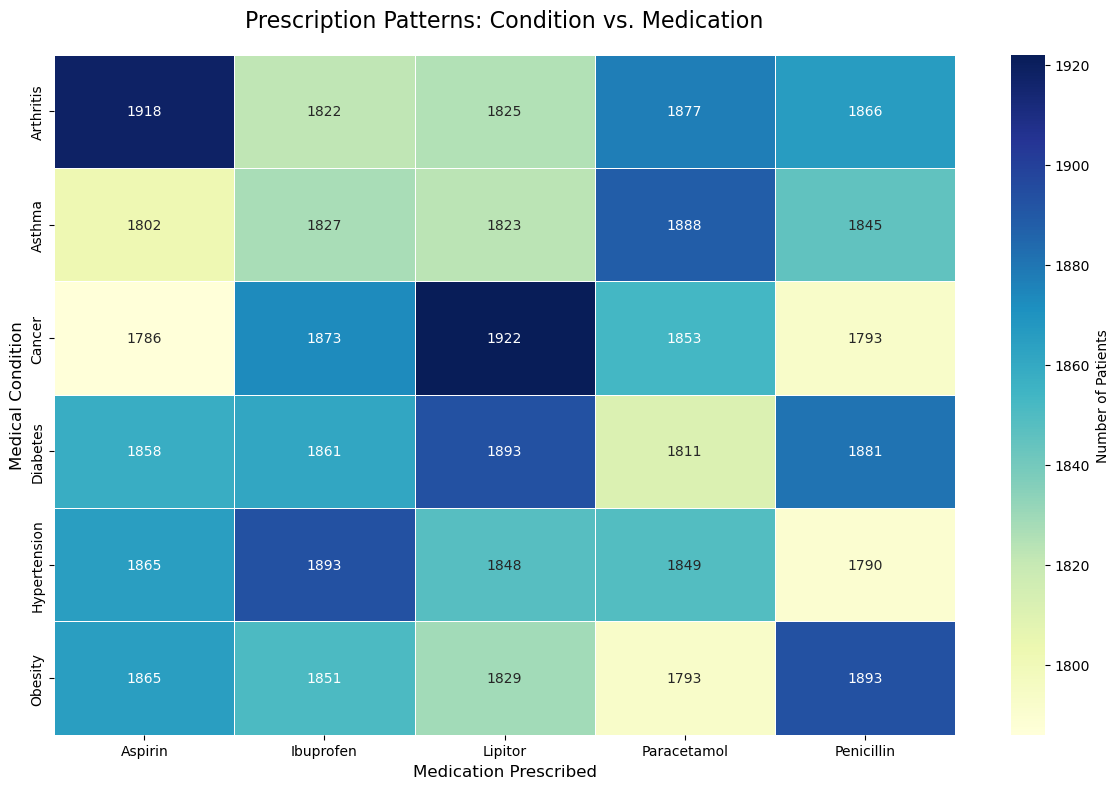

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the crosstab (counts of patients for each condition-medication pair)
# This uses your exact column names: 'medical_condition' and 'medication'
ct = pd.crosstab(df['medical_condition'], df['medication'])

# 2. Visualize with a Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    ct, 
    annot=True,          # Show the actual counts in the squares
    fmt='d',             # Format as integers
    cmap='YlGnBu',       # Yellow-Green-Blue color scale
    linewidths=.5, 
    cbar_kws={'label': 'Number of Patients'}
)

plt.title("Prescription Patterns: Condition vs. Medication", fontsize=16, pad=20)
plt.xlabel("Medication Prescribed", fontsize=12)
plt.ylabel("Medical Condition", fontsize=12)

plt.tight_layout()
plt.show()

#### Percentage based heatmap

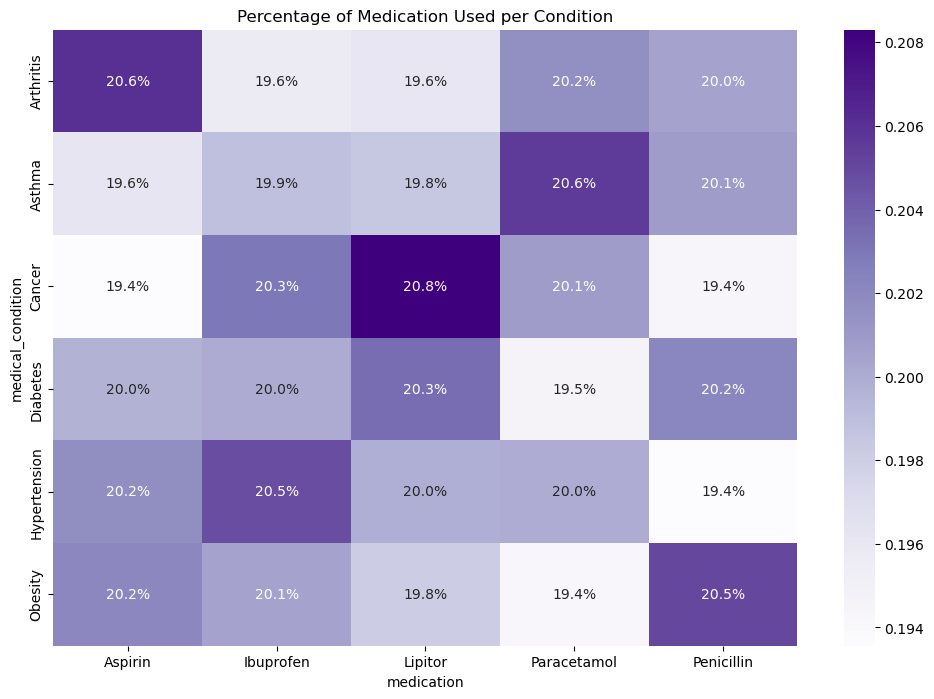

In [22]:
# Create a percentage-based heatmap
ct_pct = pd.crosstab(df['medical_condition'], df['medication'], normalize='index')

plt.figure(figsize=(12, 8))
sns.heatmap(ct_pct, annot=True, fmt='.1%', cmap='Purples')
plt.title("Percentage of Medication Used per Condition")
plt.show()

#### Insurace provider Analysis

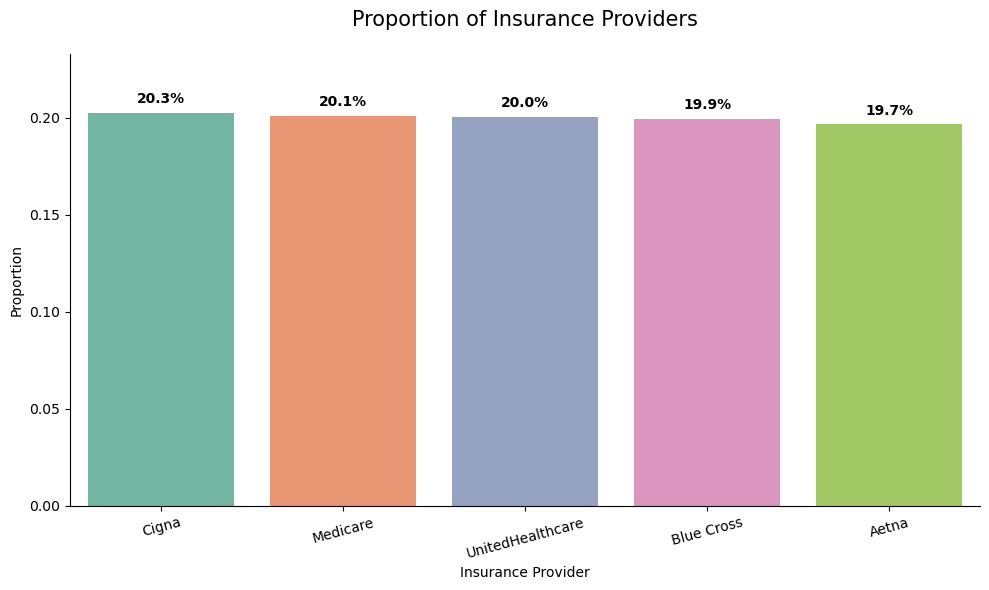

In [23]:
# Calculate proportions once to be efficient
insurance_counts = df['insurance_provider'].value_counts(normalize=True)

plt.figure(figsize=(10, 6))

# Plot with a professional palette
ax = sns.barplot(
    x=insurance_counts.index, 
    y=insurance_counts.values, 
    palette='Set2'
)

plt.title("Proportion of Insurance Providers", fontsize=15, pad=20)
plt.ylabel("Proportion")
plt.xlabel("Insurance Provider")

# Increase Y-axis limit to prevent text from hitting the top border
plt.ylim(0, insurance_counts.max() * 1.15)

#  Add percentage labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%", 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                fontweight='bold', 
                xytext=(0, 5), 
                textcoords='offset points')

# Rotate x-labels if they are long
plt.xticks(rotation=15)

sns.despine()
plt.tight_layout()
plt.show()

#### Billing by insurance

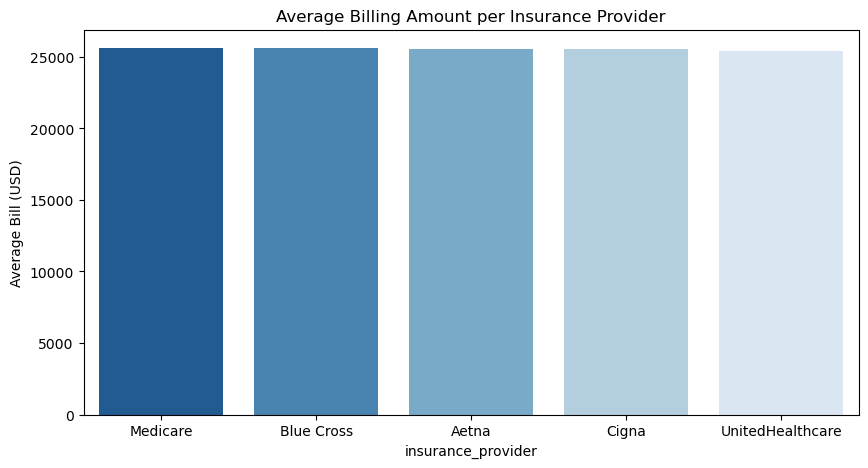

In [24]:
# Check the average billing amount per insurance provider
avg_billing = df.groupby('insurance_provider')['billing_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_billing.index, y=avg_billing.values, palette='Blues_r')
plt.title("Average Billing Amount per Insurance Provider")
plt.ylabel("Average Bill (USD)")
plt.show()

#### Admission type per insurance

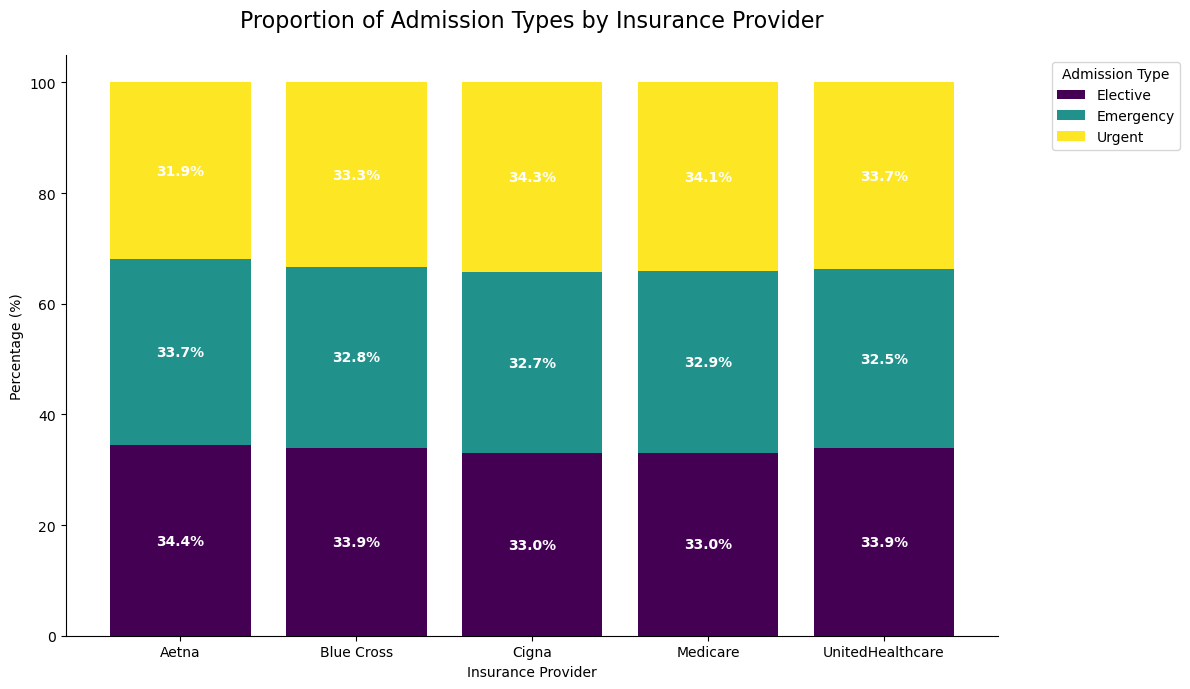

In [25]:
#Create a normalized crosstab (percentages)
# This calculates: "Of all patients under Insurance X, what % were Emergency vs. Elective?"
admission_insurance_pct = pd.crosstab(
    df['insurance_provider'], 
    df['admission_type'], 
    normalize='index'
) * 100

# Plotting as a stacked bar chart for clear proportion comparison
ax = admission_insurance_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    colormap='viridis',
    width=0.8
)

plt.title("Proportion of Admission Types by Insurance Provider", fontsize=16, pad=20)
plt.ylabel("Percentage (%)")
plt.xlabel("Insurance Provider")
plt.xticks(rotation=0) # Keeps labels horizontal for easier reading
plt.legend(title="Admission Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Only label bars taller than 5% to avoid clutter
        x, y = p.get_xy() 
        ax.annotate(f'{height:.1f}%', 
                    (x + width/2, y + height/2), 
                    ha='center', va='center', 
                    color='white', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

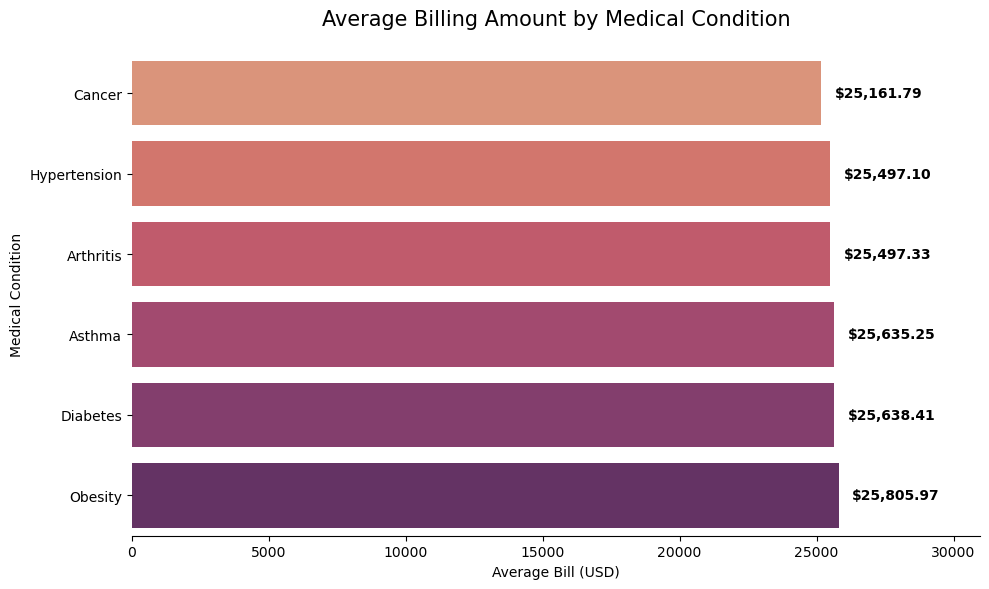

In [27]:

#  Calculate the mean and sort (your snippet)
avg_billing_per_condition = df.groupby('medical_condition')['billing_amount'].mean().sort_values()

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=avg_billing_per_condition.values, 
    y=avg_billing_per_condition.index, 
    palette="flare" # A warm gradient palette
)

# Add labels and formatting
plt.title("Average Billing Amount by Medical Condition", fontsize=15, pad=20)
plt.xlabel("Average Bill (USD)")
plt.ylabel("Medical Condition")

#  Add the exact dollar amounts to the end of each bar
for i, v in enumerate(avg_billing_per_condition.values):
    ax.text(v + 500, i, f"${v:,.2f}", va='center', fontweight='bold', fontsize=10)

# Set x-limit higher to make room for labels
plt.xlim(0, avg_billing_per_condition.max() * 1.2)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()
